Create New Train Env

In [5]:
%pip install "gymnasium[box2d]" stable-baselines3 matplotlib pandas

# IMPORTS

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, CallbackList
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env

Note: you may need to restart the kernel to use updated packages.


Create Project Folders

In [6]:

# PROJECT FOLDERS
# These folders keep logs, models, and videos organized.

BASE_DIR = "bipedalwalker_project"
LOG_DIR = os.path.join(BASE_DIR, "logs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
BEST_MODEL_DIR = os.path.join(BASE_DIR, "best_model")
VIDEO_DIR = os.path.join(BASE_DIR, "videos")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


Create New Eval Evn

In [7]:
# ============================================================
# ENVIRONMENT SETUP
# ============================================================
# BipedalWalker-v3 is the environment the agent will learn in.
# We use:
#   - a vectorized training environment for faster learning
#   - a separate evaluation environment for testing progress
#   - monitor logs so we can graph rewards with Matplotlib
# ============================================================

ENV_ID = "BipedalWalker-v3"
N_ENVS = 8

# Vectorized training environment with monitor logging
train_env = make_vec_env(
    ENV_ID,
    n_envs=N_ENVS,
    monitor_dir=LOG_DIR
)

# Separate evaluation environment
eval_env = Monitor(gym.make(ENV_ID))

print("Training and evaluation environments created.")

Training and evaluation environments created.


Wrap/ Log Env

Def PPO Hyperparameters 

In [8]:
# ============================================================
# PPO MODEL SETUP
# ============================================================
# These are solid starter settings for BipedalWalker.
# You can tune them later after you see the reward graphs.
# ============================================================

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    tensorboard_log=os.path.join(BASE_DIR, "tensorboard")
)

print("PPO model created.")

Using cpu device
PPO model created.


Create Callbacks and checkpoints 

In [9]:
# ============================================================
# CALLBACKS
# ============================================================
# CheckpointCallback:
#   Saves the model every fixed number of steps.
#
# EvalCallback:
#   Tests the agent regularly on the separate eval environment.
#   Saves the best model automatically.
# ============================================================

checkpoint_callback = CheckpointCallback(
    save_freq=50_000 // N_ENVS,
    save_path=MODEL_DIR,
    name_prefix="ppo_bipedalwalker_checkpoint"
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=BEST_MODEL_DIR,
    log_path=BEST_MODEL_DIR,
    eval_freq=25_000 // N_ENVS,
    deterministic=True,
    render=False
)

callback = CallbackList([checkpoint_callback, eval_callback])

print("Callbacks ready.")

Callbacks ready.


TRAIN

In [10]:
# ============================================================
# TRAINING
# ============================================================
# This is where the agent actually learns.
# You can increase TOTAL_TIMESTEPS later if needed.
# ============================================================

TOTAL_TIMESTEPS = 1_000_000

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    progress_bar=True
)

FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "ppo_bipedalwalker_final")
model.save(FINAL_MODEL_PATH)

print(f"Training complete. Final model saved to: {FINAL_MODEL_PATH}")

Logging to bipedalwalker_project/tensorboard/PPO_1


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 458      |
|    ep_rew_mean     | -110     |
| time/              |          |
|    fps             | 6307     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 16384    |
---------------------------------


Eval num_timesteps=25000, episode_reward=-92.42 +/- 0.06

Episode length: 113.60 +/- 1.50

...

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 65          |
|    mean_reward          | -123        |
| time/                   |             |
|    total_timesteps      | 975000      |
| train/                  |             |
|    approx_kl            | 0.013124542 |
|    clip_fraction        | 0.175       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.88       |
|    explained_variance   | 0.918       |
|    learning_rate        | 0.0003      |
|    loss                 | 1.64        |
|    n_updates            | 590         |
|    policy_gradient_loss | -0.00198    |
|    std                  | 0.824       |
|    value_loss           | 12.6        |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.23e+03 |
|    ep_rew_mean     | 127      |
| time/              |          |
|    fps             | 3394     

Eval num_timesteps=1000000, episode_reward=81.85 +/- 128.66

Episode length: 648.80 +/- 343.34

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 649         |
|    mean_reward          | 81.9        |
| time/                   |             |
|    total_timesteps      | 1000000     |
| train/                  |             |
|    approx_kl            | 0.011041241 |
|    clip_fraction        | 0.116       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.82       |
|    explained_variance   | 0.929       |
|    learning_rate        | 0.0003      |
|    loss                 | 4.77        |
|    n_updates            | 610         |
|    policy_gradient_loss | -0.00135    |
|    std                  | 0.814       |
|    value_loss           | 6.18        |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.21e+03 |
|    ep_rew_mean     | 138      |
| time/              |          |
|    fps             | 3402     

Training complete. Final model saved to: bipedalwalker_project/models/ppo_bipedalwalker_final


Save CheckPoints 

Eval Periodically

In [12]:
# ============================================================
# EVALUATE FINAL MODEL
# ============================================================
# This checks how well the final trained agent performs.
# ============================================================

mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=10,
    deterministic=True
)

print(f"Final model mean reward: {mean_reward:.2f}")
print(f"Final model standard deviation: {std_reward:.2f}")

Final model mean reward: 227.15

Final model standard deviation: 108.76

In [13]:
# ============================================================
# LOAD AND EVALUATE THE BEST MODEL
# ============================================================
# Sometimes the best saved model performs better than the
# final model, depending on how training went near the end.
# ============================================================

best_model_path = os.path.join(BEST_MODEL_DIR, "best_model.zip")

best_model = PPO.load(best_model_path)

best_mean_reward, best_std_reward = evaluate_policy(
    best_model,
    eval_env,
    n_eval_episodes=10,
    deterministic=True
)

print(f"Best model mean reward: {best_mean_reward:.2f}")
print(f"Best model standard deviation: {best_std_reward:.2f}")

Best model mean reward: 201.31

Best model standard deviation: 127.27

Plot results

In [15]:
# ============================================================
# LOAD MONITOR LOG FILES
# ============================================================
# The Monitor wrapper saves episode rewards to .monitor.csv files.
# We load them all and combine them into one DataFrame so we can
# graph training progress with Matplotlib.
# ============================================================

def load_monitor_files(log_dir):
    csv_files = glob.glob(os.path.join(log_dir, "*.monitor.csv"))
    dataframes = []

    for file in csv_files:
        df = pd.read_csv(file, skiprows=1)  # Skip metadata row
        dataframes.append(df)

    if not dataframes:
        raise FileNotFoundError("No monitor files found in the log directory.")

    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

monitor_df = load_monitor_files(LOG_DIR)

print("Monitor logs loaded successfully.")
print(monitor_df.head())

r     l           t
0 -108.624608   101  177.093227
1 -102.369047  1600  179.061905
2 -111.940031  1600  183.170189
3 -108.274283  1600  186.991749
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.926968    72  187.083580
4 -116.92696

RecursionError: maximum recursion depth exceeded

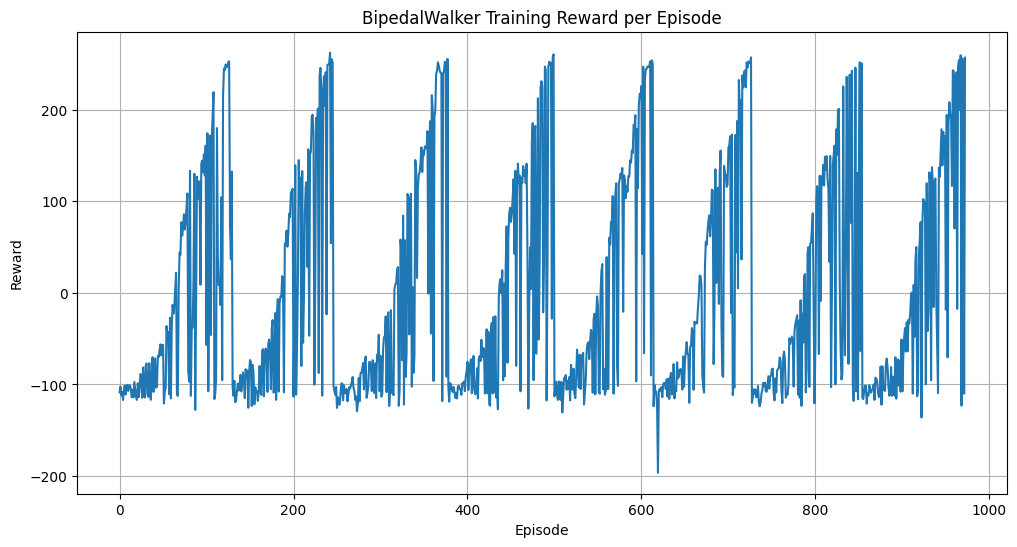

In [16]:
# ============================================================
# PLOT RAW EPISODE REWARDS
# ============================================================
# This shows the reward from each episode.
# Raw rewards are usually noisy in reinforcement learning.
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(monitor_df["r"].values)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("BipedalWalker Training Reward per Episode")
plt.grid(True)
plt.show()

In [17]:
# ============================================================
# SMOOTH REWARDS
# ============================================================
# A rolling average helps make the learning trend easier to see.
# ============================================================

window = 50
monitor_df["reward_smooth"] = monitor_df["r"].rolling(window=window).mean()

print(monitor_df[["r", "reward_smooth"]].head(10))

RecursionError: maximum recursion depth exceeded

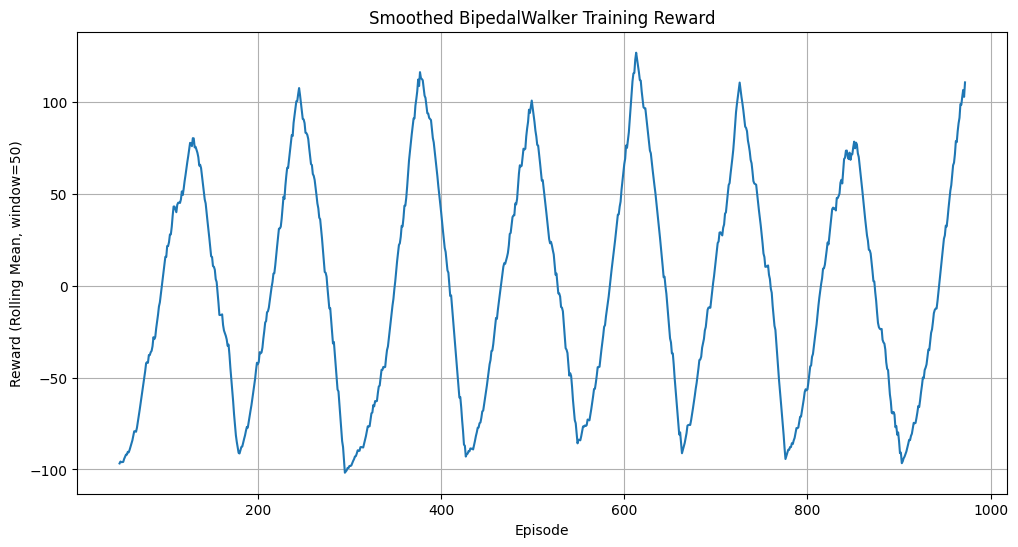

In [18]:
# ============================================================
# PLOT SMOOTHED REWARDS
# ============================================================
# This graph is much easier to use in a thesis because it shows
# the overall reward trend more clearly.
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(monitor_df["reward_smooth"].values)
plt.xlabel("Episode")
plt.ylabel(f"Reward (Rolling Mean, window={window})")
plt.title("Smoothed BipedalWalker Training Reward")
plt.grid(True)
plt.show()

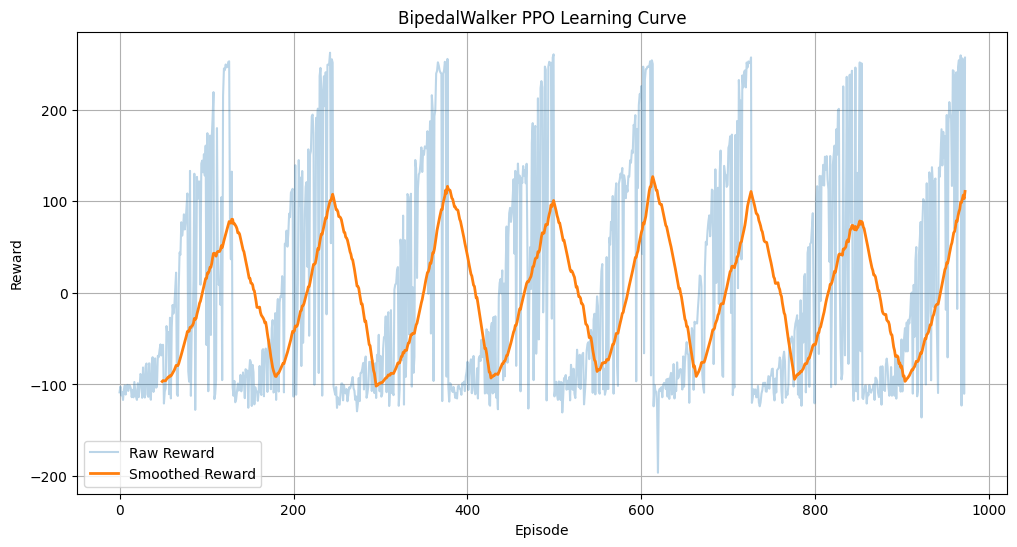

In [19]:
# ============================================================
# PLOT RAW + SMOOTHED REWARDS TOGETHER
# ============================================================
# This is the best overall graph because it shows both:
#   - the noisy episode-by-episode rewards
#   - the smoother learning trend
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(monitor_df["r"].values, alpha=0.3, label="Raw Reward")
plt.plot(monitor_df["reward_smooth"].values, linewidth=2, label="Smoothed Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("BipedalWalker PPO Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

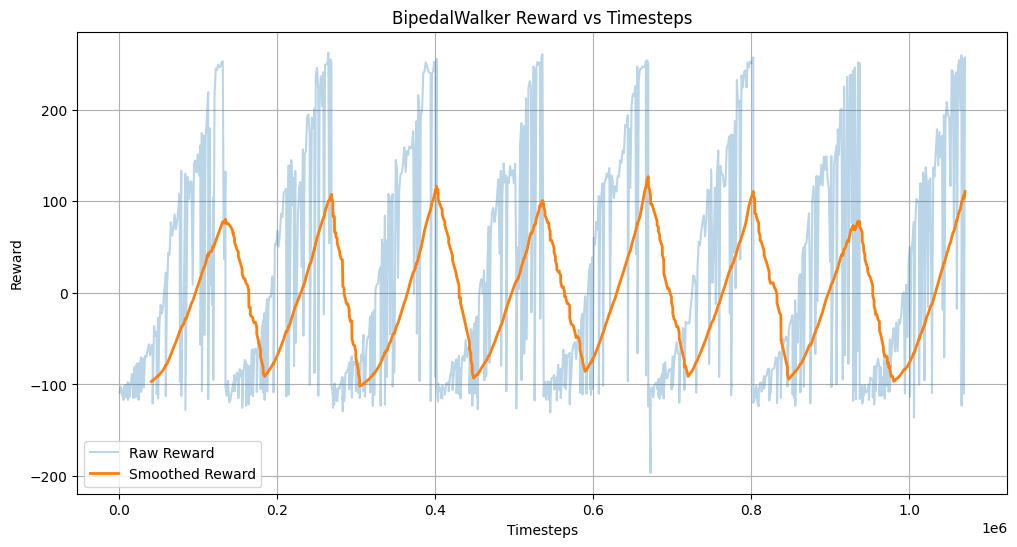

In [20]:
# ============================================================
# REWARD VS TIMESTEPS
# ============================================================
# This creates a cumulative timestep column so you can graph
# reward against total environment steps instead of episode number.
# ============================================================

monitor_df["cumulative_timesteps"] = monitor_df["l"].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(monitor_df["cumulative_timesteps"], monitor_df["r"], alpha=0.3, label="Raw Reward")
plt.plot(monitor_df["cumulative_timesteps"], monitor_df["reward_smooth"], linewidth=2, label="Smoothed Reward")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("BipedalWalker Reward vs Timesteps")
plt.legend()
plt.grid(True)
plt.show()

Record Final Run

In [21]:
# ============================================================
# WATCH THE TRAINED AGENT
# ============================================================
# This opens a render window so you can visually inspect whether
# the walker has actually learned to move well.
# ============================================================

watch_env = gym.make(ENV_ID, render_mode="human")
obs, info = watch_env.reset()

for step in range(2000):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = watch_env.step(action)

    if terminated or truncated:
        obs, info = watch_env.reset()

watch_env.close()